In [3]:
# GitHub setup

from google.colab import userdata
import os

# Load GitHub token from Colab Secrets
os.environ["GITHUB_TOKEN"] = userdata.get("NLP-II-PolitiSky24Token")

# Configure temporary GitHub authentication
!git config --global credential.helper cache
!printf "protocol=https\nhost=github.com\nusername=jakobtitz\npassword=$GITHUB_TOKEN\n\n" | git credential approve

# Clone the RoBERTa training branch
!git clone --branch JT_roberta_training https://github.com/jakobtitz/nlp-II-politiksky24.git

# Move into repository
%cd /content/nlp-II-politiksky24

# Verify setup
!git branch --show-current
!git status

Cloning into 'nlp-II-politiksky24'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 98 (delta 27), reused 65 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 469.40 KiB | 5.21 MiB/s, done.
Resolving deltas: 100% (27/27), done.
Filtering content: 100% (11/11), 305.42 MiB | 8.68 MiB/s, done.
/content/nlp-II-politiksky24
JT_roberta_training
On branch JT_roberta_training
Your branch is up to date with 'origin/JT_roberta_training'.

nothing to commit, working tree clean


---
## 1. Environment and configuration

This section defines the general setup used throughout the RoBERTa training notebook.

We:

- import the required libraries
- set the random seed for reproducibility
- define the dataset paths
- check the available compute device

In [27]:
import os
import random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
DATA_DIR = "data/preprocessed"

TRAIN_PATH = f"{DATA_DIR}/train.parquet"
VALIDATION_PATH = f"{DATA_DIR}/validation.parquet"

# Check available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


---
## 2. Load the preprocessed datasets

The fixed train and validation splits created during preprocessing are reused unchanged. The human-annotated test set is kept separate and will only be loaded during final evaluation.

We:

- load `train.parquet`
- load `validation.parquet`
- inspect their sizes and structure

In [28]:
train_table = pq.read_table(TRAIN_PATH)
validation_table = pq.read_table(VALIDATION_PATH)

print(f"Train rows: {train_table.num_rows:,}")
print(f"Validation rows: {validation_table.num_rows:,}")

print(train_table.schema)

Train rows: 12,834
Validation rows: 3,210
UserId: int64
TargetEntity: string
StanceLabel: string
ContextPosts: list<element: struct<Content: string, PostTime: string, IsAmbiguous: bool>>
  child 0, element: struct<Content: string, PostTime: string, IsAmbiguous: bool>
      child 0, Content: string
      child 1, PostTime: string
      child 2, IsAmbiguous: bool


---
## 3. Prepare RoBERTa inputs

RoBERTa requires each user-target example to be converted into a textual input that combines the supplied target with the retrieved context posts.

Before tokenizing the complete datasets, we first inspect the resulting input lengths to determine whether RoBERTa's maximum sequence length requires an explicit truncation strategy.

In this section, we:

- load the `roberta-base` tokenizer
- extract the `Content` field from `ContextPosts`
- preserve the existing order of the retrieved posts
- combine the target and context as a sequence pair
- calculate the resulting token lengths
- inspect how many examples exceed RoBERTa's maximum input length

In [26]:
from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_df = train_table.to_pandas()
validation_df = validation_table.to_pandas()

print(f"Tokenizer: {MODEL_NAME}")
print(f"Model maximum length: {tokenizer.model_max_length}")

Tokenizer: roberta-base
Model maximum length: 512


In [29]:
def build_context_text(context_posts):
    posts = [
        post["Content"]
        for post in context_posts
        if post["Content"] is not None
    ]

    # Separate individual posts explicitly within the context sequence
    return f" {tokenizer.sep_token} ".join(posts)


for df in [train_df, validation_df]:
    df["ContextText"] = df["ContextPosts"].apply(build_context_text)

In [30]:
example = train_df.iloc[0]

print("TARGET:")
print(example["TargetEntity"])

print("\nCONTEXT:")
print(example["ContextText"])

print("\nLABEL:")
print(example["StanceLabel"])

TARGET:
Harris

CONTEXT:
I don't see how you read "We are withholding our endorsement out of fear that, should he win, Donald Trump will retaliate against our newspaper" as anything but a giant "VOTE KAMALA HARRIS!!!!!!!!" statement. </s> Jill Stein is trash and cannot be trusted.

https://anonymous </s> I mean so do I, there's several people I'd want over Harris. That's...not the same as refusing to vote for or support Harris in THIS election.

Someone criticizing Harris for specific positions does not automatically equal "will not vote for her" </s> All my doom and gloom aside. If Harris needs a boring, bland white guy to balance the ticket...I'm available. </s> Assuming Harris is the pick. Biden might have endorsed her but I sure as shit hope there's been arrangements to make her the nominee with no fuss. </s> Cannot express how badly this whole "Dump Biden" thing could go if it also pulls in Harris
https://anonymous </s> Oh COME ON! Like EVERYONE agrees Bibi is terrible! </s> I'm n

In [31]:
def add_token_lengths(df):
    encodings = tokenizer(
        df["TargetEntity"].tolist(),
        df["ContextText"].tolist(),
        add_special_tokens=True,
        truncation=False,
        padding=False,
        return_length=True
    )

    df["TokenLength"] = encodings["length"]


add_token_lengths(train_df)
add_token_lengths(validation_df)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (536 > 512). Running this sequence through the model will result in indexing errors


In [32]:
def show_length_stats(df, name):
    lengths = df["TokenLength"]

    print(f"{name}")
    print(f"Min:    {lengths.min()}")
    print(f"Median: {lengths.median():.0f}")
    print(f"Mean:   {lengths.mean():.1f}")
    print(f"90%:    {lengths.quantile(0.90):.0f}")
    print(f"95%:    {lengths.quantile(0.95):.0f}")
    print(f"99%:    {lengths.quantile(0.99):.0f}")
    print(f"Max:    {lengths.max()}")
    print(f"> 512:  {(lengths > 512).mean() * 100:.1f}%")
    print()


show_length_stats(train_df, "Train")
show_length_stats(validation_df, "Validation")

Train
Min:    9
Median: 216
Mean:   224.3
90%:    322
95%:    358
99%:    454
Max:    1567
> 512:  0.5%

Validation
Min:    10
Median: 213
Mean:   220.9
90%:    319
95%:    356
99%:    446
Max:    599
> 512:  0.5%



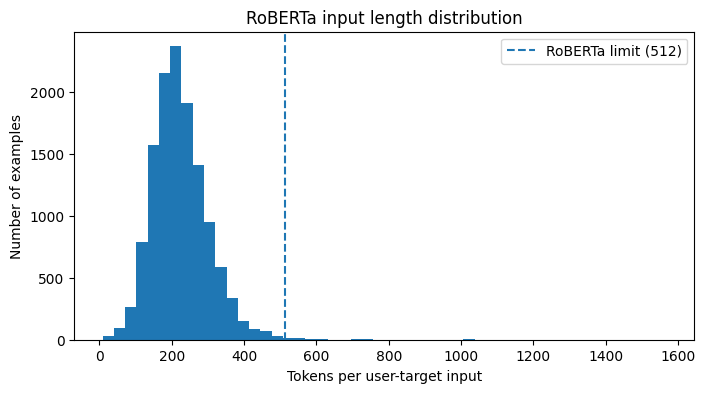

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(train_df["TokenLength"], bins=50)
plt.axvline(512, linestyle="--", label="RoBERTa limit (512)")
plt.xlabel("Tokens per user-target input")
plt.ylabel("Number of examples")
plt.title("RoBERTa input length distribution")
plt.legend()
plt.show()

Only around 0.5% of the training and validation examples exceed RoBERTa's maximum sequence length of 512 tokens. Since this affects only a very small fraction of the data, we use standard truncation instead of introducing a more complex long-sequence strategy.

For overlength examples:

- the maximum sequence length is set to 512 tokens
- only the context is truncated
- the supplied target is always preserved

---
## 4. Encode labels and tokenize the datasets

The stance labels must be converted to numerical class IDs before training. The target and retrieved context are then tokenized as a sequence pair for RoBERTa.

Based on the input-length analysis above, sequences exceeding 512 tokens are truncated only on the context side so that the supplied target is always preserved.

We:

- define a fixed mapping between stance labels and class IDs
- encode the labels in the training and validation datasets
- tokenize target and context as a sequence pair
- truncate only the context when the 512-token limit is exceeded
- keep padding dynamic for the later batching step

In [33]:
LABEL2ID = {
    "Against": 0,
    "Favor": 1,
    "Neither": 2
}

ID2LABEL = {value: key for key, value in LABEL2ID.items()}

for df in [train_df, validation_df]:
    df["Label"] = df["StanceLabel"].map(LABEL2ID)

    # Ensure that all labels were mapped successfully
    assert df["Label"].notna().all()
print("Label mapping:")
print(LABEL2ID)

Label mapping:
{'Against': 0, 'Favor': 1, 'Neither': 2}


In [13]:
# Tokenize training and validation data
def tokenize_dataframe(df):
    return tokenizer(
        df["TargetEntity"].tolist(),
        df["ContextText"].tolist(),
        max_length=512,
        truncation="only_second",
        padding=False
    )


train_encodings = tokenize_dataframe(train_df)
validation_encodings = tokenize_dataframe(validation_df)

In [34]:
# Sanity checks
train_encodings["labels"] = train_df["Label"].tolist()
validation_encodings["labels"] = validation_df["Label"].tolist()

example_idx = 0

print(f"Target: {train_df.iloc[example_idx]['TargetEntity']}")
print(f"Stance label: {train_df.iloc[example_idx]['StanceLabel']}")
print(f"Encoded label: {train_encodings['labels'][example_idx]}")
print(f"Tokenized length: {len(train_encodings['input_ids'][example_idx])}")

assert max(map(len, train_encodings["input_ids"])) <= 512
assert max(map(len, validation_encodings["input_ids"])) <= 512

print("All tokenized inputs are within the 512-token limit.")

Target: Harris
Stance label: Favor
Encoded label: 1
Tokenized length: 261
All tokenized inputs are within the 512-token limit.


---
## 5. Create PyTorch datasets and dynamic padding

The tokenized inputs are converted into PyTorch datasets that can be passed to the Hugging Face Trainer. Since the input sequences have different lengths, padding is applied dynamically during batching instead of padding every example to the maximum length of 512 tokens. This reduces unnecessary computation and GPU memory usage.

We:

- create PyTorch datasets for train and validation data
- keep sequences at their original tokenized length
- pad each batch only to the longest sequence it contains
- verify the resulting batch structure

In [35]:
from torch.utils.data import Dataset

class StanceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["labels"])

    def __getitem__(self, idx):
        return {
            key: torch.tensor(values[idx])
            for key, values in self.encodings.items()
        }

train_dataset = StanceDataset(train_encodings)
validation_dataset = StanceDataset(validation_encodings)

print(f"Train examples: {len(train_dataset):,}")
print(f"Validation examples: {len(validation_dataset):,}")

Train examples: 12,834
Validation examples: 3,210


In [16]:
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    return_tensors="pt"
)

sample_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=data_collator
)

sample_batch = next(iter(sample_loader))

for key, value in sample_batch.items():
    print(f"{key}: {value.shape}")

input_ids: torch.Size([4, 261])
attention_mask: torch.Size([4, 261])
labels: torch.Size([4])


---
## 6. Initialize RoBERTa classifier

We use the pretrained `roberta-base` model and add a classification head for the three stance classes. All model parameters are fine-tuned during training rather than freezing the pretrained encoder.

We:

- load `roberta-base` for sequence classification
- configure the model for the three stance labels
- attach the previously defined label mappings
- verify the model configuration and trainable parameters

In [17]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS = len(LABEL2ID)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    label2id=LABEL2ID,
    id2label=ID2LABEL
)

print(f"Model: {MODEL_NAME}")
print(f"Number of labels: {model.config.num_labels}")
print(f"Label mapping: {model.config.label2id}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Number of labels: 3
Label mapping: {'Against': 0, 'Favor': 1, 'Neither': 2}


In [18]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 124,647,939
Trainable parameters: 124,647,939


---
## 7. Define evaluation metrics

Model performance is evaluated on the validation set during training. Since the stance classes are imbalanced, Macro-F1 is used as the main metric because it gives equal importance to each class regardless of its frequency.

The shared evaluation utilities are defined in `src/utils.py` so that the same metrics can later be reused for both classifiers and the controlled input experiments.

We:

- compute Macro-F1 as the main validation metric
- report accuracy as an additional overall metric
- compute precision, recall, and F1 for each stance class
- provide the metrics in the format expected by the Hugging Face Trainer


In [19]:
from src.utils import compute_trainer_metrics


def compute_metrics(eval_pred):
    return compute_trainer_metrics(
        eval_pred,
        labels=list(ID2LABEL.keys()),
        label_names=list(ID2LABEL.values()),
    )

---
## 8. Configure and train RoBERTa

The model is fine-tuned using a standard training configuration rather than an extensive hyperparameter search. Since the goal is to analyse model behaviour rather than optimize benchmark performance, we keep the main training parameters fixed.

To reduce GPU memory usage, training uses mixed precision and gradient accumulation. The model is evaluated after each epoch, and the checkpoint with the highest validation Macro-F1 is retained.

We:

- train for three epochs with a learning rate of `2e-5`
- use a physical batch size of 8 and an effective batch size of 16
- evaluate and save a checkpoint after each epoch
- select the best checkpoint based on validation Macro-F1
- store checkpoints in Google Drive
- fine-tune the model using the Hugging Face Trainer

In [20]:
from google.colab import drive

drive.mount("/content/drive")

CHECKPOINT_DIR = "/content/drive/MyDrive/NLP_II/checkpoints/roberta_base"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Checkpoints will be stored in: {CHECKPOINT_DIR}")

Mounted at /content/drive
Checkpoints will be stored in: /content/drive/MyDrive/NLP_II/checkpoints/roberta_base


In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # Basic fine-tuning parameters
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Batch size
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # Evaluation and checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,

    # Mixed precision on GPU
    fp16=torch.cuda.is_available(),

    # Reproducibility
    seed=SEED,
    data_seed=SEED,

    # Logging
    logging_strategy="steps",
    logging_steps=100,
    report_to="none"
)

In [22]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Against,Recall Against,F1 Against,Precision Favor,Recall Favor,F1 Favor,Precision Neither,Recall Neither,F1 Neither
1,0.934330,0.455924,0.845794,0.828585,0.901544,0.888396,0.894922,0.718708,0.835681,0.772793,0.854326,0.784708,0.818039
2,0.792234,0.422051,0.854829,0.839945,0.911649,0.883323,0.897262,0.803514,0.787167,0.795257,0.803030,0.853119,0.827317
3,0.545027,0.462849,0.854829,0.839193,0.887787,0.908053,0.897806,0.790769,0.804382,0.797517,0.842661,0.802817,0.822257


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 9. Save the trained model

After training, the checkpoint with the highest validation Macro-F1 is loaded automatically. We save this model separately from the intermediate training checkpoints so that the same frozen model can be reused for all subsequent evaluation and intervention experiments.

We:

- save the best-performing RoBERTa model
- save the corresponding tokenizer
- store the training history for later inspection
- record the selected checkpoint and its validation Macro-F1

In [23]:
FINAL_MODEL_DIR = "/content/drive/MyDrive/NLP_II/models/roberta_base_best"

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

# trainer.model already contains the best checkpoint
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print(f"Best model saved to: {FINAL_MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/drive/MyDrive/NLP_II/models/roberta_base_best


In [23]:
training_history = pd.DataFrame(trainer.state.log_history)

training_history.to_csv(
    f"{FINAL_MODEL_DIR}/training_history.csv",
    index=False
)

In [36]:
import json

training_summary = {
    "model": MODEL_NAME,
    "best_checkpoint": os.path.basename(trainer.state.best_model_checkpoint),
    "best_validation_macro_f1": trainer.state.best_metric,
    "epochs": training_args.num_train_epochs,
    "learning_rate": training_args.learning_rate,
    "train_batch_size": training_args.per_device_train_batch_size,
    "gradient_accumulation_steps": training_args.gradient_accumulation_steps,
    "effective_batch_size": (
        training_args.per_device_train_batch_size
        * training_args.gradient_accumulation_steps
    ),
    "max_length": 512,
    "seed": SEED,
    "label2id": LABEL2ID,
}

with open(f"{FINAL_MODEL_DIR}/training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=4)

print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")
print(f"Best validation Macro-F1: {trainer.state.best_metric:.4f}")

Best checkpoint: /content/drive/MyDrive/NLP_II/checkpoints/roberta_base/checkpoint-1606
Best validation Macro-F1: 0.8399
